Testing the Sensors ability to correctly diagnose component states

Diagnosis Sensor Accuracy: 81.19%


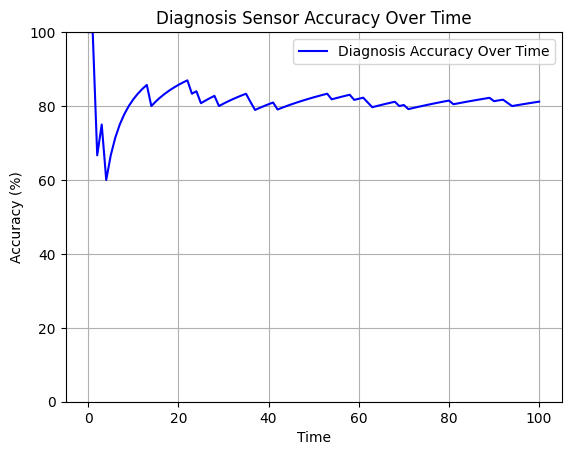

In [9]:
from sensor_objects.DiagnosisSensor import DiagnosisSensor
from component_objects.component_exponential import ExponentialComponent

import numpy as np
import matplotlib.pyplot as plt

num_time_steps = 100

comp = ExponentialComponent("basic component", MTTF=5, MTTR=2)
comp.simulate(num_time_steps)

# print(type(comp.history[5,1]))

sensor = DiagnosisSensor("basic diagnosis sensor", comp)
sensed_states = np.zeros(num_time_steps+1, dtype=int)
for i in range(num_time_steps+1):
    sensor.observation_matrix(i)
    sensed_states[i] = sensor.sensorLogic(int(comp.history[i,1]), i)

# plot true vs sensed states
# plt.plot(comp.history[:,0], sensed_states, 'ks', markersize= 10,  label="Diagnosed Component State")
# comp.plot_history()

# calculate the accuracy
correct_diagnoses = np.sum(sensed_states == comp.history[:,1])
accuracy = correct_diagnoses / (num_time_steps + 1) * 100
print(f"Diagnosis Sensor Accuracy: {accuracy:.2f}%")

# plot accuracy over time
accuracy_over_time = np.cumsum(sensed_states == comp.history[:,1]) / (np.arange(num_time_steps + 1) + 1) * 100
plt.figure()
plt.plot(comp.history[:,0], accuracy_over_time, 'b-', label="Diagnosis Accuracy Over Time")
plt.xlabel("Time")
plt.ylabel("Accuracy (%)")
plt.title("Diagnosis Sensor Accuracy Over Time")
plt.ylim(0, 100)
plt.grid()
plt.legend()
plt.show()

Text(0, 0.5, 'Bounded Exponential Value')

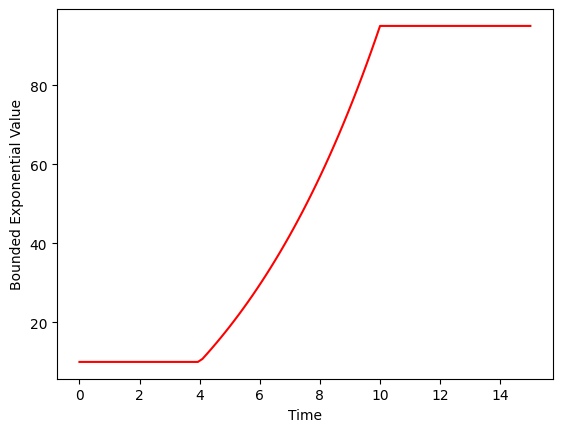

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def bounded_exponential(
    t: float,
    t0: float,
    tf: float,
    min_value: float,
    max_value: float
) -> float:
    """
    Exponential growth from min_value to max_value
    starting at t0 and ending at tf.
    """

    if t <= t0:
        return min_value

    if t >= tf:
        return max_value

    # Normalize time to [0, 1]
    tau = (t - t0) / (tf - t0)

    # Exponential curve normalized to hit endpoints exactly
    # exp(0) = 1 → min_value
    # exp(1) normalized → max_value
    growth = (np.exp(tau) - 1) / (np.e - 1)

    return min_value + growth * (max_value - min_value)

plt.figure()
times = np.linspace(0, 15, num_time_steps)
t_0 = 4
t_f = 10
min_val = 10
max_val = 95
values = [bounded_exponential(t, t_0, t_f, min_val, max_val) for t in times]
plt.plot(times, values, 'r-')
plt.xlabel("Time")
plt.ylabel("Bounded Exponential Value")

7.0


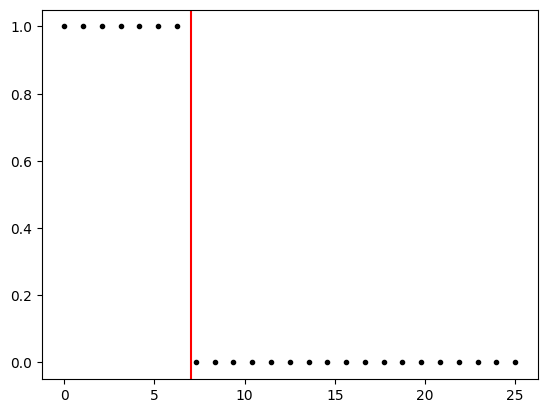

In [13]:
from sensor_objects.PrognosisSensor import PrognosisSensor
from component_objects.component_exponential import ExponentialComponent

import matplotlib.pyplot as plt
import numpy as np

num_time_steps = 100
comp = ExponentialComponent("basic component", MTTF=5, MTTR=2)
sensor = PrognosisSensor("basic prognosis sensor", comp)
sensor.prob_diagnosis_at_t_fail = 0.99

print(comp.time_to_failure)

t_array = np.linspace(0, 25, 25)
sensor_prognosis = np.zeros_like(t_array)
for i,t in enumerate(t_array):
    sensor_prognosis[i] = sensor.sensorLogic(t)

plt.figure()
plt.plot(t_array, sensor_prognosis, '.k')
plt.axvline(comp.time_to_failure, color='r')